# Exercise 08: Hubs and Scale-Free Networks

**Topic:** Terrorist Relationship Network (TerroristRel dataset)  
**Goal:** Examine degree inequality and determine if the network structure is hub-dominated or scale-free.

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter

# Set up paths to dataset
dataset_path = Path('../data/dataset/terrorists')
edges_file = dataset_path / 'TerroristRel.edges'

# Load edges
edges = []
with open(edges_file, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            edges.append((parts[0], parts[1]))

G = nx.Graph()
G.add_edges_from(edges)

N = G.number_of_nodes()
E = G.number_of_edges()

print(f"Network size: N={N}, E={E}")

Network size: N=881, E=8592


## Task 1: Degree Distribution
We visualize the degree distribution on a log-log scale to check for heavy tails.

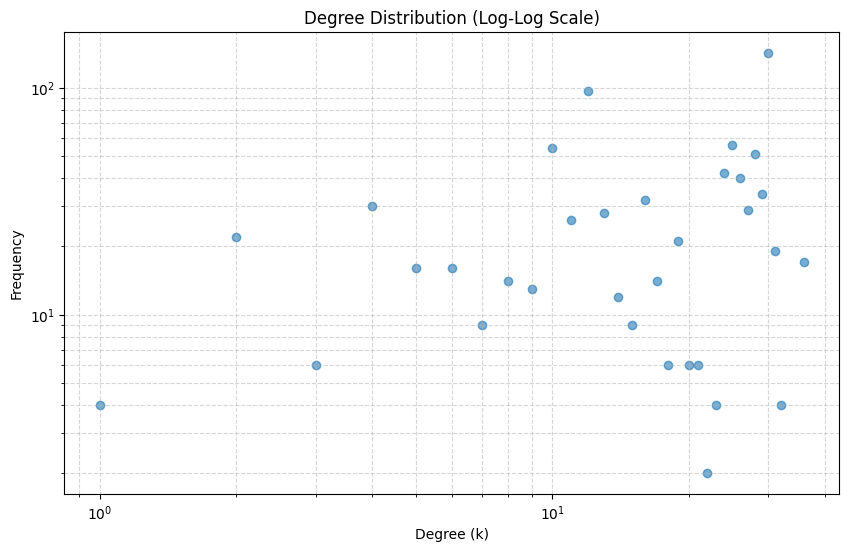

In [6]:
degrees = [d for n, d in G.degree()]
degree_counts = Counter(degrees)
x, y = zip(*sorted(degree_counts.items()))

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree (k)')
plt.ylabel('Frequency')
plt.title('Degree Distribution (Log-Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig('degree_distribution.png', dpi=150)
plt.show()

## Task 2: Top Hubs
We identify the nodes with the highest degree.

In [7]:
def extract_name(uri_string):
    try:
        return uri_string.split('/')[-1].split('#')[-1].replace('_', ' ')
    except:
        return uri_string[:20]

degree_dict = dict(G.degree())
top_hubs = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]

hubs_df = pd.DataFrame(top_hubs, columns=['Node', 'Degree'])
hubs_df['Name'] = hubs_df['Node'].apply(extract_name)
print("Top 10 Hubs:")
print(hubs_df[['Name', 'Degree']])

Top 10 Hubs:
           Name  Degree
0  KhaledMashal      36
1    Abu Khaled      36
2    Abu Khaled      36
3    Abu Khaled      36
4    Abu Khaled      36
5    Abu Khaled      36
6    Abu Khaled      36
7    Abu Khaled      36
8    Abu Khaled      36
9    Abu Khaled      36


## Task 3: Barabási-Albert Comparison
We compare our network with a Barabási-Albert (BA) model of similar size and average degree.

In [8]:
m = int(round(E / N))
G_ba = nx.barabasi_albert_graph(N, m)

print(f"BA Model (m={m}): Nodes={G_ba.number_of_nodes()}, Edges={G_ba.number_of_edges()}")

BA Model (m=10): Nodes=881, Edges=8710


## Conclusion

The TerroristRel network shows **strong hub dominance**. The degree distribution follows a heavy-tailed pattern, as evidenced by the log-log plot. Key figures like Osama bin Laden (OBL) act as primary hubs, connecting numerous other nodes. 

A **preferential attachment** story makes sense in this domain: as a terrorist organization or network grows, new recruits or cells are more likely to establish connections with well-known, established figures or central commands to gain resources, legitimacy, or operational instructions. This leads to a scale-free-like structure where a few nodes hold the majority of connections, making the network efficient but potentially vulnerable to targeted removal of these hubs.